# Final Comparison - Raw vs Reconstruction Acceleration Experiments

This notebook is **analysis-only**. It does not train or modify any model.

It combines the five test conditions:

| Condition | Training domain | Test domain | Main question |
|---|---|---|---|
| A | Raw | Raw | Baseline held-out-user performance |
| B | Raw | Reconstruction | Frozen-transfer / domain-shift cost |
| C | Reconstruction | Reconstruction | Recoverable information in reconstruction |
| D-Raw | Raw + Reconstruction | Raw | Does mixed training preserve raw performance? |
| D-Recon | Raw + Reconstruction | Reconstruction | Does mixed training improve robustness to reconstruction? |

The loader supports the **legacy A/B artifact names** produced by the original notebooks and the standardized `summary.csv` schema used by C/D.


In [4]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repository_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root containing the 'snn' directory."
    )


REPOSITORY_ROOT = find_repository_root(Path.cwd())
print("Repository root:", REPOSITORY_ROOT)


Repository root: /home/ted/project/writingring-viz


## Artifact locations


In [5]:
A_DIR = REPOSITORY_ROOT / "notebooks/artifacts/acceleration_cnn_representation"
B_DIR = REPOSITORY_ROOT / "notebooks/artifacts/experiment_B_reconstruction_frozen_cnn"
C_DIR = REPOSITORY_ROOT / "notebooks/artifacts/experiment_C_reconstruction_trained"
D_DIR = REPOSITORY_ROOT / "notebooks/artifacts/experiment_D_mixed_training"

OUTPUT_DIR = (
    REPOSITORY_ROOT
    / "notebooks/artifacts/final_acceleration_reconstruction_comparison"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, path in {
    "A": A_DIR,
    "B": B_DIR,
    "C": C_DIR,
    "D": D_DIR,
}.items():
    print(f"{name}: {path}")


A: /home/ted/project/writingring-viz/notebooks/artifacts/acceleration_cnn_representation
B: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_B_reconstruction_frozen_cnn
C: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_C_reconstruction_trained
D: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_D_mixed_training


## Robust summary loaders

A and B predate the shared `save_representation_evaluation()` format, so their metrics are normalized here into the same key-value schema as C/D.


In [6]:
CORE_METRICS = [
    "CNN_test_balanced_accuracy",
    "CNN_test_macro_f1",
    "kNN_test_balanced_accuracy",
    "prototype_test_balanced_accuracy",
    "linear_probe_test_balanced_accuracy",
    "retrieval_macro_mAP",
    "retrieval_micro_mAP",
    "SameLabel_macro_at_1",
    "SameLabel_micro_at_1",
    "D_intra_macro",
    "D_inter_centroids",
    "D_inter_over_D_intra",
    "NMI_arithmetic",
    "ARI",
    "silhouette_macro",
    "silhouette_micro",
]

DIRECTION = {
    "CNN_test_balanced_accuracy": "higher",
    "CNN_test_macro_f1": "higher",
    "kNN_test_balanced_accuracy": "higher",
    "prototype_test_balanced_accuracy": "higher",
    "linear_probe_test_balanced_accuracy": "higher",
    "retrieval_macro_mAP": "higher",
    "retrieval_micro_mAP": "higher",
    "SameLabel_macro_at_1": "higher",
    "SameLabel_micro_at_1": "higher",
    "D_intra_macro": "lower",
    "D_inter_centroids": "context",
    "D_inter_over_D_intra": "higher",
    "NMI_arithmetic": "higher",
    "ARI": "higher",
    "silhouette_macro": "higher",
    "silhouette_micro": "higher",
}


def _one_row_csv(path: Path) -> pd.Series:
    if not path.is_file():
        raise FileNotFoundError(path)
    frame = pd.read_csv(path)
    if len(frame) != 1:
        raise ValueError(f"Expected one row in {path}, found {len(frame)}")
    return frame.iloc[0]


def load_a_metrics(directory: Path) -> pd.Series:
    standardized = directory / "summary.csv"
    if standardized.is_file():
        return _one_row_csv(standardized)

    primary_path = directory / "primary_results.csv"
    complementary_path = directory / "complementary_results.csv"
    if not primary_path.is_file() or not complementary_path.is_file():
        raise FileNotFoundError(
            "Experiment A requires either summary.csv or both legacy files: "
            f"{primary_path.name}, {complementary_path.name}"
        )

    primary = _one_row_csv(primary_path)
    complementary = _one_row_csv(complementary_path)
    merged = pd.concat([primary, complementary])
    merged = merged[~merged.index.duplicated(keep="first")]
    return merged


def load_b_metrics(directory: Path) -> tuple[pd.Series, pd.Series | None]:
    standardized = directory / "summary.csv"
    if standardized.is_file():
        return _one_row_csv(standardized), None

    legacy = directory / "experiment_B_raw_vs_reconstruction_metrics.csv"
    if not legacy.is_file():
        raise FileNotFoundError(
            "Experiment B requires either summary.csv or legacy comparison: "
            f"{legacy}"
        )

    table = pd.read_csv(legacy, index_col=0)
    if "recon_test_B" not in table.columns:
        raise ValueError(f"{legacy} is missing recon_test_B")
    raw = table["raw_test"] if "raw_test" in table.columns else None
    return table["recon_test_B"], raw


def load_standard_metrics(path: Path) -> pd.Series:
    return _one_row_csv(path)


def take_core(series: pd.Series, condition: str) -> pd.Series:
    missing = [metric for metric in CORE_METRICS if metric not in series.index]
    if missing:
        raise KeyError(
            f"{condition} is missing required comparison metrics: {missing}"
        )
    return pd.Series(
        {metric: float(series[metric]) for metric in CORE_METRICS},
        name=condition,
    )


## Load A/B/C/D results


In [7]:
a_all = load_a_metrics(A_DIR)
b_all, b_raw_reference = load_b_metrics(B_DIR)
c_all = load_standard_metrics(C_DIR / "summary.csv")
d_raw_all = load_standard_metrics(D_DIR / "raw_test/summary.csv")
d_recon_all = load_standard_metrics(D_DIR / "reconstruction_test/summary.csv")

conditions = {
    "A_raw_to_raw": take_core(a_all, "A_raw_to_raw"),
    "B_raw_to_reconstruction": take_core(b_all, "B_raw_to_reconstruction"),
    "C_reconstruction_to_reconstruction": take_core(
        c_all,
        "C_reconstruction_to_reconstruction",
    ),
    "D_mixed_to_raw": take_core(d_raw_all, "D_mixed_to_raw"),
    "D_mixed_to_reconstruction": take_core(
        d_recon_all,
        "D_mixed_to_reconstruction",
    ),
}

comparison = pd.DataFrame(conditions)
comparison.insert(
    0,
    "direction",
    pd.Series(DIRECTION).reindex(comparison.index),
)
display(comparison)


,direction,A_raw_to_raw,B_raw_to_reconstruction,C_reconstruction_to_reconstruction,D_mixed_to_raw,D_mixed_to_reconstruction
CNN_test_balanced_accuracy,higher,0.426768,0.223485,0.527086,0.555285,0.549904
CNN_test_macro_f1,higher,0.381170,0.166865,0.511598,0.561578,0.531567
kNN_test_balanced_accuracy,higher,0.591931,0.343224,0.583484,0.552850,0.603355
prototype_test_balanced_accuracy,higher,0.558562,0.321880,0.565085,0.591570,0.589466
linear_probe_test_balanced_accuracy,higher,0.564875,0.364478,0.604317,0.527086,0.589165
retrieval_macro_mAP,higher,0.403784,0.257328,0.337047,0.445663,0.467784
retrieval_micro_mAP,higher,0.413855,0.265179,0.347733,0.458257,0.478651
SameLabel_macro_at_1,higher,0.491101,0.284722,0.511845,0.526365,0.566017
SameLabel_micro_at_1,higher,0.503937,0.299213,0.519685,0.535433,0.574803
D_intra_macro,lower,0.064386,0.053717,0.072672,0.060568,0.059902


## A/B baseline consistency check

The legacy B notebook recomputed raw-test metrics using the frozen A model before evaluating reconstruction. Where those values are available, they should match Experiment A up to numerical tolerance. A mismatch indicates a protocol or artifact-version problem and should be investigated before interpreting B.


In [8]:
if b_raw_reference is None:
    print("No B raw-reference column is available; skipping A/B consistency check.")
else:
    shared = [
        metric
        for metric in CORE_METRICS
        if metric in b_raw_reference.index and metric in a_all.index
    ]
    consistency = pd.DataFrame(
        {
            "A": [float(a_all[metric]) for metric in shared],
            "B_raw_reference": [float(b_raw_reference[metric]) for metric in shared],
        },
        index=shared,
    )
    consistency["absolute_difference"] = (
        consistency["A"] - consistency["B_raw_reference"]
    ).abs()
    display(consistency)
    print("Max absolute difference:", consistency["absolute_difference"].max())


No B raw-reference column is available; skipping A/B consistency check.


## Decision-oriented deltas

These deltas answer different causal questions. Positive/negative signs are not universally "good" because `D_intra_macro` is better when lower and `D_inter_centroids` is contextual.


In [9]:
deltas = pd.DataFrame(index=CORE_METRICS)
deltas["B_minus_A"] = (
    comparison["B_raw_to_reconstruction"]
    - comparison["A_raw_to_raw"]
)
deltas["C_minus_A"] = (
    comparison["C_reconstruction_to_reconstruction"]
    - comparison["A_raw_to_raw"]
)
deltas["D_raw_minus_A"] = (
    comparison["D_mixed_to_raw"]
    - comparison["A_raw_to_raw"]
)
deltas["D_recon_minus_B"] = (
    comparison["D_mixed_to_reconstruction"]
    - comparison["B_raw_to_reconstruction"]
)
deltas["D_recon_minus_C"] = (
    comparison["D_mixed_to_reconstruction"]
    - comparison["C_reconstruction_to_reconstruction"]
)
deltas.insert(0, "direction", pd.Series(DIRECTION))
display(deltas)


,direction,B_minus_A,C_minus_A,D_raw_minus_A,D_recon_minus_B,D_recon_minus_C
CNN_test_balanced_accuracy,higher,-0.203283,0.100319,0.128517,0.326419,0.022817
CNN_test_macro_f1,higher,-0.214305,0.130428,0.180408,0.364702,0.019969
kNN_test_balanced_accuracy,higher,-0.248707,-0.008448,-0.039081,0.260131,0.019871
prototype_test_balanced_accuracy,higher,-0.236682,0.006524,0.033009,0.267587,0.024381
linear_probe_test_balanced_accuracy,higher,-0.200397,0.039442,-0.037789,0.224687,-0.015152
retrieval_macro_mAP,higher,-0.146457,-0.066737,0.041879,0.210456,0.130737
retrieval_micro_mAP,higher,-0.148676,-0.066122,0.044402,0.213473,0.130918
SameLabel_macro_at_1,higher,-0.206379,0.020743,0.035263,0.281295,0.054173
SameLabel_micro_at_1,higher,-0.204724,0.015748,0.031496,0.275591,0.055118
D_intra_macro,lower,-0.010668,0.008286,-0.003818,0.006185,-0.012769


## Classification/readout overview


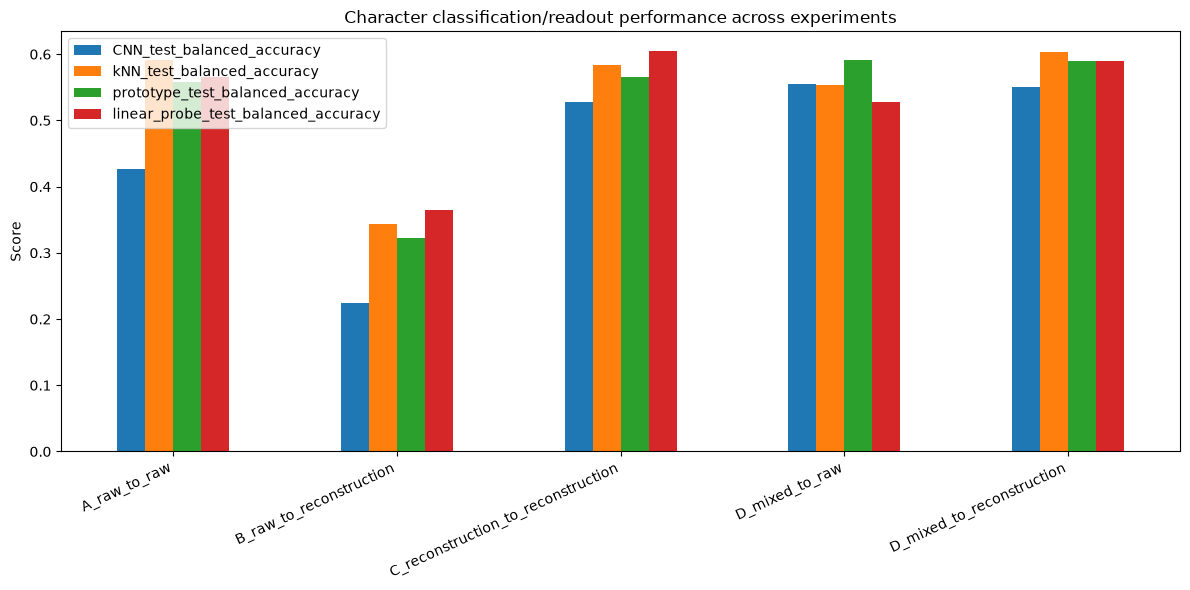

In [10]:
READOUT_METRICS = [
    "CNN_test_balanced_accuracy",
    "kNN_test_balanced_accuracy",
    "prototype_test_balanced_accuracy",
    "linear_probe_test_balanced_accuracy",
]

plot_table = comparison.loc[READOUT_METRICS].drop(columns="direction").T
ax = plot_table.plot(kind="bar", figsize=(12, 6))
ax.set_ylabel("Score")
ax.set_title("Character classification/readout performance across experiments")
ax.set_ylim(bottom=0)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "classification_readouts.png", dpi=180)
plt.show()


## Representation geometry and retrieval overview


In [11]:
GEOMETRY_METRICS = [
    "retrieval_macro_mAP",
    "SameLabel_macro_at_1",
    "D_inter_over_D_intra",
    "silhouette_macro",
    "NMI_arithmetic",
    "ARI",
]

display(comparison.loc[GEOMETRY_METRICS])


,direction,A_raw_to_raw,B_raw_to_reconstruction,C_reconstruction_to_reconstruction,D_mixed_to_raw,D_mixed_to_reconstruction
retrieval_macro_mAP,higher,0.403784,0.257328,0.337047,0.445663,0.467784
SameLabel_macro_at_1,higher,0.491101,0.284722,0.511845,0.526365,0.566017
D_inter_over_D_intra,higher,1.277400,0.979046,1.290856,1.371523,1.642475
silhouette_macro,higher,0.062748,-0.029009,0.051191,0.089155,0.135483
NMI_arithmetic,higher,0.547830,0.514941,0.528369,0.677305,0.627598
ARI,higher,0.265755,0.239014,0.250843,0.412172,0.421010


## Paired reconstruction invariance: B vs D

If both paired-summary artifacts are present, this directly asks whether mixed training makes the embedding more invariant to reconstruction than the raw-trained frozen model.


In [12]:
B_PAIRED_CANDIDATES = [
    B_DIR / "paired_preservation_summary.csv",
    B_DIR / "paired_summary.csv",
]
D_PAIRED = D_DIR / "paired_preservation/paired_summary.csv"

b_paired_path = next(
    (path for path in B_PAIRED_CANDIDATES if path.is_file()),
    None,
)

paired_comparison = None
if b_paired_path is None or not D_PAIRED.is_file():
    print("Paired B/D artifacts are incomplete; skipping paired comparison.")
    print("B candidates:", B_PAIRED_CANDIDATES)
    print("D expected:", D_PAIRED)
else:
    b_paired = _one_row_csv(b_paired_path)
    d_paired = _one_row_csv(D_PAIRED)
    paired_keys = [
        "mean_embedding_cosine_similarity",
        "median_embedding_cosine_similarity",
        "mean_embedding_cosine_distance",
        "median_embedding_cosine_distance",
        "prediction_agreement",
    ]
    paired_comparison = pd.DataFrame(
        {
            "B_raw_trained": [float(b_paired[key]) for key in paired_keys],
            "D_mixed_trained": [float(d_paired[key]) for key in paired_keys],
        },
        index=paired_keys,
    )
    paired_comparison["D_minus_B"] = (
        paired_comparison["D_mixed_trained"]
        - paired_comparison["B_raw_trained"]
    )
    display(paired_comparison)


Paired B/D artifacts are incomplete; skipping paired comparison.
B candidates: [PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/experiment_B_reconstruction_frozen_cnn/paired_preservation_summary.csv'), PosixPath('/home/ted/project/writingring-viz/notebooks/artifacts/experiment_B_reconstruction_frozen_cnn/paired_summary.csv')]
D expected: /home/ted/project/writingring-viz/notebooks/artifacts/experiment_D_mixed_training/paired_preservation/paired_summary.csv


## Compact interpretation panel

The lines below expose the main CNN balanced-accuracy comparisons without replacing the full representation analysis.


In [13]:
cnn_ba = comparison.loc["CNN_test_balanced_accuracy"]

interpretation = pd.DataFrame(
    [
        {
            "question": "Frozen-transfer cost (B - A)",
            "value": float(
                cnn_ba["B_raw_to_reconstruction"]
                - cnn_ba["A_raw_to_raw"]
            ),
        },
        {
            "question": "Recon recoverability vs raw baseline (C - A)",
            "value": float(
                cnn_ba["C_reconstruction_to_reconstruction"]
                - cnn_ba["A_raw_to_raw"]
            ),
        },
        {
            "question": "Mixed-training raw impact (D-raw - A)",
            "value": float(
                cnn_ba["D_mixed_to_raw"]
                - cnn_ba["A_raw_to_raw"]
            ),
        },
        {
            "question": "Mixed-training reconstruction gain (D-recon - B)",
            "value": float(
                cnn_ba["D_mixed_to_reconstruction"]
                - cnn_ba["B_raw_to_reconstruction"]
            ),
        },
        {
            "question": "Mixed vs recon-specialized (D-recon - C)",
            "value": float(
                cnn_ba["D_mixed_to_reconstruction"]
                - cnn_ba["C_reconstruction_to_reconstruction"]
            ),
        },
    ]
)
display(interpretation)


,question,value
0,Frozen-transfer cost (B - A),-0.203283
1,Recon recoverability vs raw baseline (C - A),0.100319
2,Mixed-training raw impact (D-raw - A),0.128517
3,Mixed-training reconstruction gain (D-recon - B),0.326419
4,Mixed vs recon-specialized (D-recon - C),0.022817


## Export final comparison artifacts


In [14]:
comparison.to_csv(OUTPUT_DIR / "core_metric_comparison.csv")
deltas.to_csv(OUTPUT_DIR / "decision_deltas.csv")
interpretation.to_csv(OUTPUT_DIR / "cnn_balanced_accuracy_deltas.csv", index=False)

if paired_comparison is not None:
    paired_comparison.to_csv(
        OUTPUT_DIR / "paired_invariance_B_vs_D.csv"
    )

metadata = {
    "A_dir": str(A_DIR),
    "B_dir": str(B_DIR),
    "C_dir": str(C_DIR),
    "D_dir": str(D_DIR),
    "conditions": list(conditions),
    "core_metrics": CORE_METRICS,
}
(OUTPUT_DIR / "comparison_inputs.json").write_text(
    json.dumps(metadata, indent=2) + "\n",
    encoding="utf-8",
)

print("Saved final comparison artifacts to:", OUTPUT_DIR)


Saved final comparison artifacts to: /home/ted/project/writingring-viz/notebooks/artifacts/final_acceleration_reconstruction_comparison


## Interpretation guide

Use the full table rather than a single metric:

- **A high, B low, C near A:** reconstruction preserves task information, but raw-to-reconstruction domain shift is large.
- **A high, B low, C also low:** reconstruction likely removes task-relevant information.
- **C > A with improved geometry:** reconstruction may act as a useful denoising/bottleneck transform.
- **D-Raw near or above A and D-Recon above B:** mixed training is reducing domain sensitivity without sacrificing the raw domain.
- **D-Recon above B but D-Raw substantially below A:** robustness to reconstruction may have been purchased at a raw-domain cost.
- **Higher paired cosine similarity and prediction agreement in D than B:** direct evidence that mixed training made the learned representation more reconstruction-invariant.


## Matched CNN probe-complexity ladder

This compact view reads standardized saved A/B/C/D summaries for the three CNN probes. Probe complexity means **feature-extraction complexity** (the convolutional receptive-field/channel hierarchy), not a pure parameter-count comparison. No metrics are recomputed in this notebook.


In [15]:
PROBES = ("cnn_s", "cnn_m", "cnn_l")
PROBE_LABELS = {"cnn_s": "CNN-S", "cnn_m": "CNN-M", "cnn_l": "CNN-L"}
A_BASE = REPOSITORY_ROOT / "notebooks/artifacts/acceleration_cnn_representation"
B_BASE = REPOSITORY_ROOT / "notebooks/artifacts/experiment_B_reconstruction_frozen_cnn"
C_BASE = REPOSITORY_ROOT / "notebooks/artifacts/experiment_C_reconstruction_trained"
D_BASE = REPOSITORY_ROOT / "notebooks/artifacts/experiment_D_mixed_training"

def _probe_path(base: Path, probe: str) -> Path:
    candidate = base / probe
    # Legacy CNN-L artifacts predate probe subdirectories.
    return candidate if candidate.exists() else base if probe == "cnn_l" else candidate

def _metric(directory: Path, filename: str, key: str) -> float:
    path = directory / filename
    if not path.is_file():
        raise FileNotFoundError(f"Missing standardized artifact: {path}")
    frame = pd.read_csv(path)
    if len(frame) != 1 or key not in frame.columns:
        raise ValueError(f"Expected one-row {key!r} artifact: {path}")
    return float(frame.iloc[0][key])

rows = []
for probe in PROBES:
    a_dir, b_dir, c_dir, d_dir = (_probe_path(base, probe) for base in (A_BASE, B_BASE, C_BASE, D_BASE))
    a = _metric(a_dir, "summary.csv", "CNN_test_balanced_accuracy")
    b = _metric(b_dir, "summary.csv", "CNN_test_balanced_accuracy")
    c = _metric(c_dir, "summary.csv", "CNN_test_balanced_accuracy")
    d_raw = _metric(d_dir / "raw_test", "summary.csv", "CNN_test_balanced_accuracy")
    d_recon = _metric(d_dir / "reconstruction_test", "summary.csv", "CNN_test_balanced_accuracy")
    rows.append({"Probe": PROBE_LABELS[probe], "A Raw": a, "B Frozen→Recon": b, "C Recon": c, "D Raw": d_raw, "D Recon": d_recon, "A-C": a - c, "A-B": a - b})
comparison_table = pd.DataFrame(rows).set_index("Probe")
display(comparison_table.style.format("{:.3f}"))
comparison_table.to_csv(OUTPUT_DIR / "probe_complexity_comparison.csv")


,A Raw,B Frozen→Recon,C Recon,D Raw,D Recon,A-C,A-B
Probe,,,,,,,
CNN-S,0.071,0.083,0.059,0.188,0.248,0.011,-0.013
CNN-M,0.280,0.265,0.279,0.309,0.340,0.001,0.016
CNN-L,0.544,0.207,0.613,0.548,0.670,-0.069,0.337


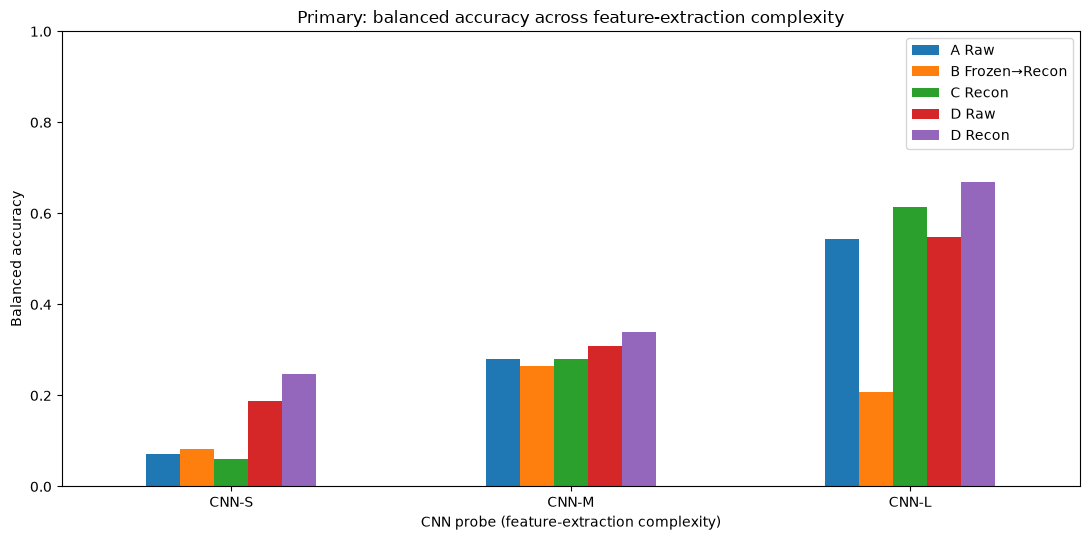

,A Raw,B Frozen→Recon,C Recon,D Raw,D Recon
CNN-S,0.021,0.013,0.017,0.132,0.179
CNN-M,0.244,0.194,0.240,0.251,0.304
CNN-L,0.524,0.145,0.586,0.513,0.655


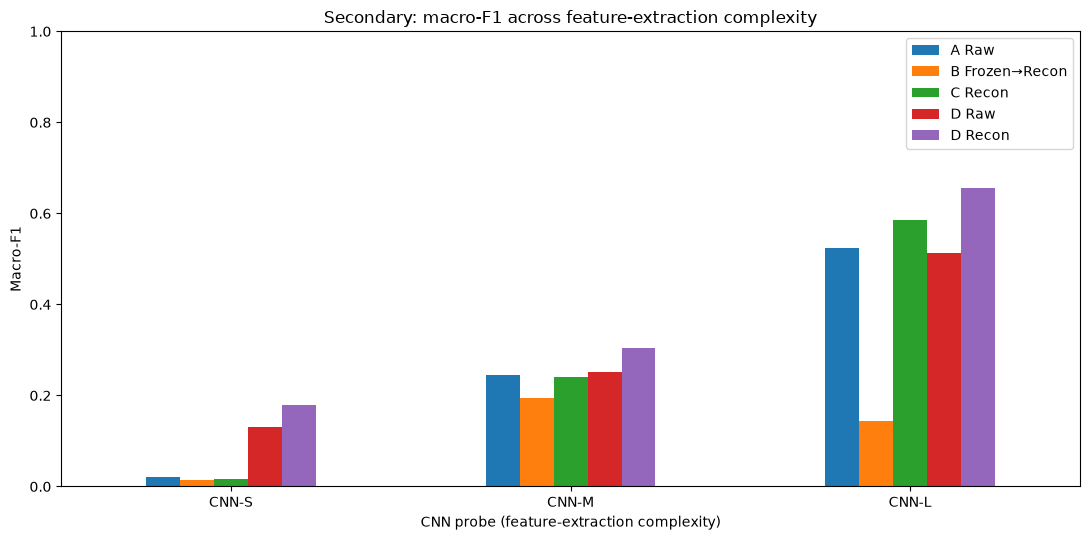

In [16]:
# Balanced accuracy is primary; macro-F1 is shown separately when present in all artifacts.
ba_plot = comparison_table[["A Raw", "B Frozen→Recon", "C Recon", "D Raw", "D Recon"]]
ax = ba_plot.plot(kind="bar", figsize=(11, 5.5), ylim=(0, 1), ylabel="Balanced accuracy", title="Primary: balanced accuracy across feature-extraction complexity")
ax.set_xlabel("CNN probe (feature-extraction complexity)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "probe_complexity_balanced_accuracy.png", dpi=180)
plt.show()

f1_rows = []
for probe in PROBES:
    a_dir, b_dir, c_dir, d_dir = (_probe_path(base, probe) for base in (A_BASE, B_BASE, C_BASE, D_BASE))
    paths = [(a_dir, "A Raw"), (b_dir, "B Frozen→Recon"), (c_dir, "C Recon"), (d_dir / "raw_test", "D Raw"), (d_dir / "reconstruction_test", "D Recon")]
    values = {label: _metric(directory, "summary.csv", "CNN_test_macro_f1") for directory, label in paths}
    f1_rows.append(pd.Series(values, name=PROBE_LABELS[probe]))
macro_f1_table = pd.DataFrame(f1_rows)
display(macro_f1_table.style.format("{:.3f}"))
macro_f1_table.to_csv(OUTPUT_DIR / "probe_complexity_macro_f1.csv")
ax = macro_f1_table.plot(kind="bar", figsize=(11, 5.5), ylim=(0, 1), ylabel="Macro-F1", title="Secondary: macro-F1 across feature-extraction complexity")
ax.set_xlabel("CNN probe (feature-extraction complexity)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "probe_complexity_macro_f1.png", dpi=180)
plt.show()
